# 02 Profitability Analysis

## Objective
To analysis Category Profitability, Channel Analysis, Marketing ROI, and Recommendation for business strategies.
Evaluate true profitability after discounts, refunds, product costs, shipping, platform fees, transaction fees, and marketing spend. Answer the project business questions with defensible metrics, visual evidence, and actionable recommendations.

### Business Questions
1. What is the profit margin by product category, and what recorded cost components help explain the differences?
2. How does profitability vary across Website, Mobile App, Marketplace, and Social Commerce?
3. What are return rates by category and channel, and how much recorded revenue was refunded?
4. Which marketing platforms generate the strongest aggregate ROAS, CPC, and CPA performance?
5. If marketing spend must be reduced by 20%, which historically lower-ROAS platform-month combinations should be prioritized for review?

In [98]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter


orders = pd.read_csv("../data/processed/orders.csv")
products = pd.read_csv("../data/processed/products.csv")
marketing = pd.read_csv("../data/processed/marketing.csv")

### 1. KPI Definitions
- **Gross Revenue:** sum of revenue before discounts/refunds.
- **Net Revenue:** gross revenue minus discounts and refunds.
- **Profit:** net revenue minus product, shipping, platform, and transaction costs.
- **Profit Margin:** total profit / total net revenue.
- **Return Rate:** returned orders / total orders.
- **ROAS:** attributed marketing revenue / marketing spend.
- **CPA:** spend / conversions.
- **CPC:** spend / clicks.

In [99]:
total_orders = orders["order_id"].nunique()
gross_revenue = orders["gross_revenue"].sum()
net_revenue = orders["net_revenue"].sum()
total_costs = orders["total_costs"].sum()
profit = orders["profit"].sum()
profit_margin = profit / net_revenue
returned_orders = (orders["returned"] == "Yes").sum()
refunds = orders["refund_amount"].sum()
avg_order_value = net_revenue / total_orders

headline_kpis = pd.DataFrame({
    "KPI": ["Total Orders", "Gross Revenue", "Net Revenue", "Total Costs", "Profit", "Profit Margin", "Returned Orders",  "Refund Amount", "Average Order Value"],
    "Value": [total_orders, gross_revenue, net_revenue, total_costs, profit, profit_margin, returned_orders, refunds, avg_order_value]
})
display(headline_kpis)

,KPI,Value
0,Total Orders,2000.000000
1,Gross Revenue,277969.130000
2,Net Revenue,236318.370000
3,Total Costs,179984.540000
4,Profit,56333.830000
5,Profit Margin,0.238381
6,Returned Orders,144.000000
7,Refund Amount,20582.450000
8,Average Order Value,118.159185


### Overall Performance
The dataset contains 2,000 orders. Gross revenue is approximately **$277.97K**, net revenue **$236.32K**, and recorded profit **$56.33K**, giving an aggregate profit margin of approximately **23.84%**. The overall return rate is **7.20%**, with **$20.58K** recorded as refunds.

### 2. Category Profitability
Profit margin is calculated from category totals rather than averaging order-level margins.

In [100]:
category_profitability = (
    orders.groupby("primary_category")
    .agg(
        orders=("order_id", "count"),
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        total_costs=("total_costs", "sum"),
        profit=("profit", "sum"),
        refund_amount=("refund_amount", "sum")
    ).reset_index()
)
category_profitability["profit_margin"] = category_profitability["profit"] / category_profitability["net_revenue"]
category_profitability["avg_order_value"] = category_profitability["net_revenue"] / category_profitability["orders"]
category_profitability = category_profitability.sort_values("profit", ascending=False)
display(category_profitability.round(4))

,primary_category,orders,gross_revenue,net_revenue,total_costs,profit,refund_amount,profit_margin,avg_order_value
3,Electronics,267,52876.49,44885.84,30912.38,13973.46,4078.27,0.3113,168.1118
7,Toys,257,39081.00,33595.68,24809.43,8786.25,2469.81,0.2615,130.7225
6,Sports,292,37453.25,32329.83,24733.20,7596.63,2008.44,0.2350,110.7186
4,Food & Beverage,247,36878.52,30662.69,23070.92,7591.77,3504.56,0.2476,124.1404
5,Home & Kitchen,200,30879.43,26359.76,19671.19,6688.57,2340.10,0.2537,131.7988
2,Clothing,293,37515.60,31383.13,25110.65,6272.48,3209.21,0.1999,107.1097
0,Beauty,205,20871.36,18254.07,15079.19,3174.88,865.70,0.1739,89.0442
1,Books,239,22413.48,18847.37,16597.58,2249.79,2106.36,0.1194,78.8593


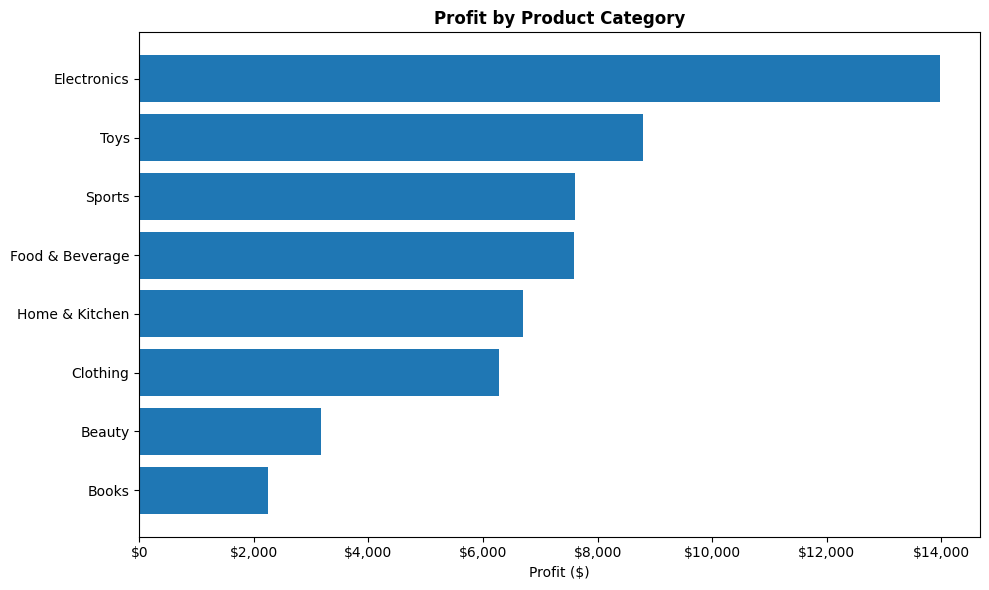

In [101]:
plot_df = category_profitability.sort_values("profit")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["primary_category"], plot_df["profit"])
ax.set_title("Profit by Product Category", fontweight="bold")
ax.set_xlabel("Profit ($)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../outputs/images/category_profit.png", dpi=300, bbox_inches="tight")
plt.show()

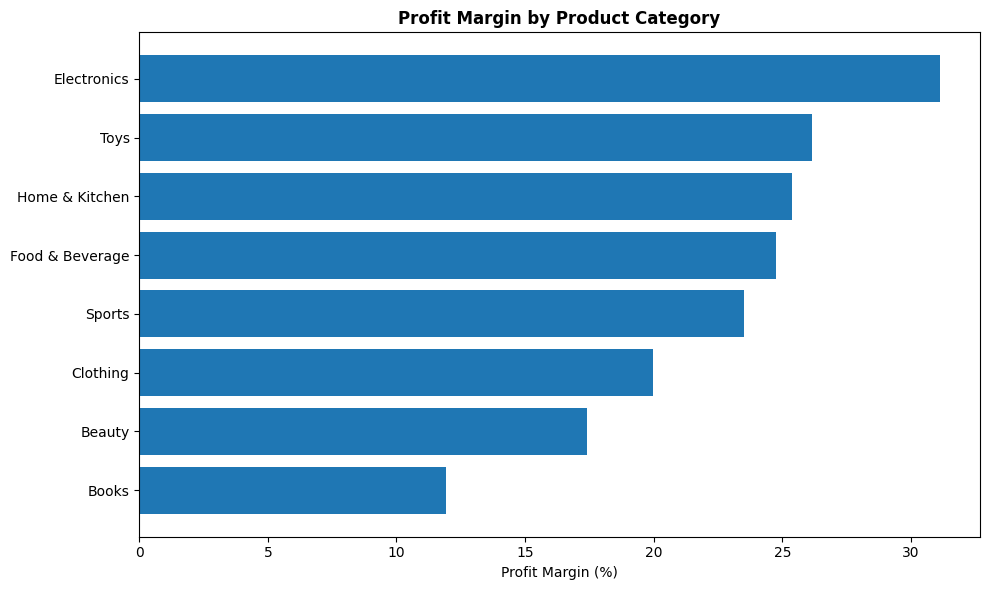

In [102]:
plot_df = category_profitability.sort_values("profit_margin")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["primary_category"], plot_df["profit_margin"] * 100)
ax.set_title("Profit Margin by Product Category", fontweight="bold")
ax.set_xlabel("Profit Margin (%)")
plt.tight_layout()
plt.savefig("../outputs/images/category_profit_margin.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding:** Electronics is the strongest category by both profit and margin (about **$13.97K profit; 31.1% margin**). Books has the weakest margin (about **11.9%**). The next section tests which recorded components are associated with this gap.

### 3. Category Profitability Drivers
Use gross revenue as a common denominator for comparing revenue leakage and cost burden across differently sized categories.

In [103]:
category_drivers = (
    orders.groupby("primary_category")
    .agg(
        gross_revenue=("gross_revenue", "sum"), net_revenue=("net_revenue", "sum"),
        product_cost=("product_cost", "sum"), shipping_cost=("shipping_cost", "sum"),
        discount_amount=("discount_amount", "sum"), refund_amount=("refund_amount", "sum"),
        platform_fee=("platform_fee", "sum"), transaction_fee=("transaction_fee", "sum"),
        profit=("profit", "sum")
    ).reset_index()
)
cost_columns = ["product_cost", "shipping_cost", "discount_amount", "refund_amount", "platform_fee", "transaction_fee"]
for c in cost_columns:
    category_drivers[f"{c}_pct"] = category_drivers[c] / category_drivers["gross_revenue"] * 100
category_drivers["profit_margin"] = category_drivers["profit"] / category_drivers["net_revenue"] * 100
category_driver_summary = category_drivers[["primary_category"] + [f"{c}_pct" for c in cost_columns] + ["profit_margin"]].sort_values("profit_margin", ascending=False)
display(category_driver_summary.round(2))

,primary_category,product_cost_pct,shipping_cost_pct,discount_amount_pct,refund_amount_pct,platform_fee_pct,transaction_fee_pct,profit_margin
3,Electronics,38.00,13.50,7.40,7.71,4.13,2.84,31.13
7,Toys,39.94,17.25,7.72,6.32,3.42,2.87,26.15
5,Home & Kitchen,39.99,16.16,7.06,7.58,4.67,2.89,25.37
4,Food & Beverage,38.77,17.47,7.35,9.50,3.43,2.89,24.76
6,Sports,41.90,18.46,8.32,5.36,2.79,2.89,23.50
2,Clothing,40.90,19.84,7.79,8.55,3.28,2.91,19.99
0,Beauty,41.16,24.79,8.39,4.15,3.35,2.95,17.39
1,Books,39.96,27.94,6.51,9.40,3.12,3.03,11.94


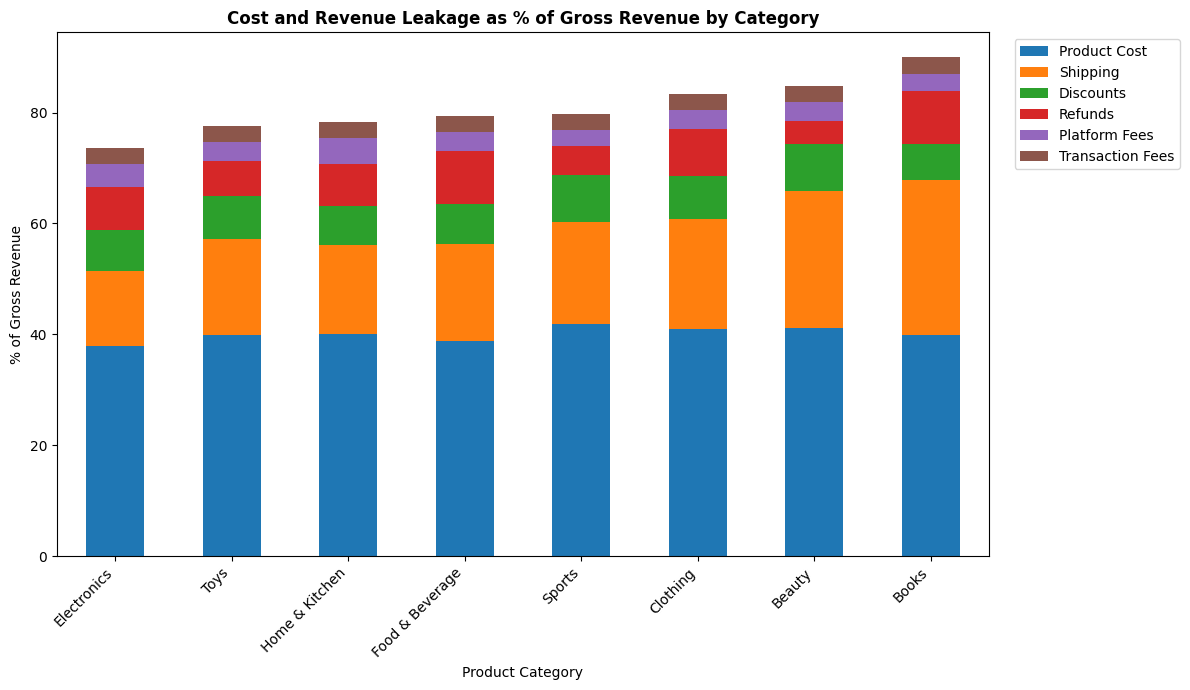

In [104]:
plot_data = category_driver_summary.set_index("primary_category")[[f"{c}_pct" for c in cost_columns]]
ax = plot_data.plot(kind="bar", stacked=True, figsize=(12, 7))
ax.set_title("Cost and Revenue Leakage as % of Gross Revenue by Category", fontweight="bold")
ax.set_xlabel("Product Category")
ax.set_ylabel("% of Gross Revenue")
plt.xticks(rotation=45, ha="right")
plt.legend(["Product Cost", "Shipping", "Discounts", "Refunds", "Platform Fees", "Transaction Fees"], bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/images/category_cost_drivers.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding:** Product-cost ratios for Electronics and Books are relatively similar, while shipping is a much larger burden for Books (about **27.9% of gross revenue**) than Electronics (about **13.5%**). Beauty also has a high shipping burden (about **24.8%**) despite relatively low refund leakage. These are associations in the supplied financial data, not proof of operational causes.

### 4. Channel Profitability
Compare revenue, profit per order, margin, return rate, and the impact of platform fees.

In [105]:
channel_profitability = (
    orders.groupby("channel")
    .agg(
        orders=("order_id", "count"), gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"), total_costs=("total_costs", "sum"),
        profit=("profit", "sum"), 
        refund_amount=("refund_amount", "sum"), platform_fee=("platform_fee", "sum")
    ).reset_index()
)
channel_profitability["avg_order_value"] = channel_profitability["net_revenue"] / channel_profitability["orders"]
channel_profitability["profit_per_order"] = channel_profitability["profit"] / channel_profitability["orders"]
channel_profitability["profit_margin"] = channel_profitability["profit"] / channel_profitability["net_revenue"]
channel_profitability["platform_fee_pct_gross"] = channel_profitability["platform_fee"] / channel_profitability["gross_revenue"]
channel_profitability = channel_profitability.sort_values("profit", ascending=False)
display(channel_profitability.round(4))

,channel,orders,gross_revenue,net_revenue,total_costs,profit,refund_amount,platform_fee,avg_order_value,profit_per_order,profit_margin,platform_fee_pct_gross
3,Website,795,111165.14,92990.55,67872.09,25118.46,9383.68,0.00,116.9692,31.5955,0.2701,0.0000
1,Mobile App,589,82725.94,71893.39,50500.09,21393.30,5324.17,0.00,122.0601,36.3214,0.2976,0.0000
0,Marketplace,419,57631.44,49505.06,43053.53,6451.53,3492.95,7949.69,118.1505,15.3974,0.1303,0.1379
2,Social Commerce,197,26446.61,21929.37,18558.83,3370.54,2381.65,1944.93,111.3166,17.1093,0.1537,0.0735


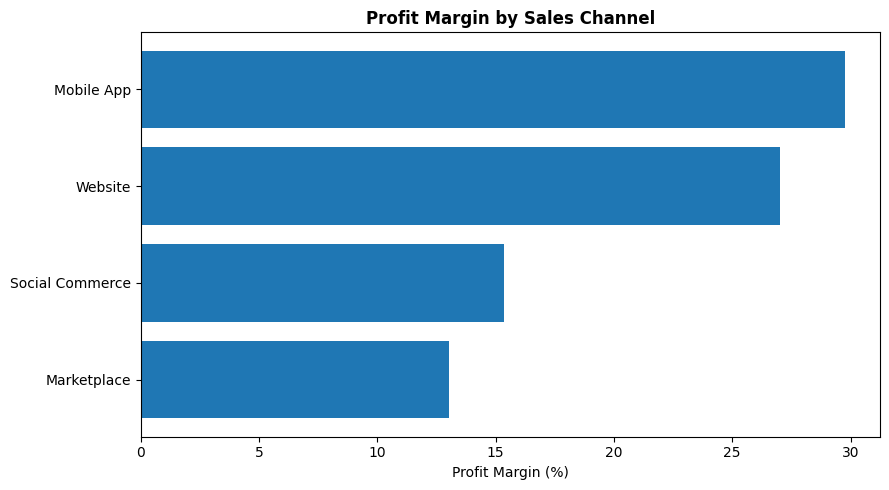

In [106]:
plot_df = channel_profitability.sort_values("profit_margin")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["channel"], plot_df["profit_margin"] * 100)
ax.set_title("Profit Margin by Sales Channel", fontweight="bold")
ax.set_xlabel("Profit Margin (%)")
plt.tight_layout()
plt.savefig("../outputs/images/channel_profit_margin.png", dpi=300, bbox_inches="tight")
plt.show()

In [107]:
channel_drivers = (
    orders.groupby("channel")
    .agg(
        gross_revenue=("gross_revenue", "sum"), net_revenue=("net_revenue", "sum"),
        product_cost=("product_cost", "sum"), shipping_cost=("shipping_cost", "sum"),
        discount_amount=("discount_amount", "sum"), refund_amount=("refund_amount", "sum"),
        platform_fee=("platform_fee", "sum"), transaction_fee=("transaction_fee", "sum"), profit=("profit", "sum")
    ).reset_index()
)
for c in cost_columns:
    channel_drivers[f"{c}_pct"] = channel_drivers[c] / channel_drivers["gross_revenue"] * 100
channel_drivers["profit_margin"] = channel_drivers["profit"] / channel_drivers["net_revenue"] * 100
channel_driver_summary = channel_drivers[["channel"] + [f"{c}_pct" for c in cost_columns] + ["profit_margin"]].sort_values("profit_margin", ascending=False)
display(channel_driver_summary.round(2))

,channel,product_cost_pct,shipping_cost_pct,discount_amount_pct,refund_amount_pct,platform_fee_pct,transaction_fee_pct,profit_margin
1,Mobile App,39.73,18.40,6.66,6.44,0.00,2.92,29.76
3,Website,40.06,18.11,7.91,8.44,0.00,2.89,27.01
2,Social Commerce,40.30,19.63,8.08,9.01,7.35,2.89,15.37
0,Marketplace,39.70,18.33,8.04,6.06,13.79,2.88,13.03


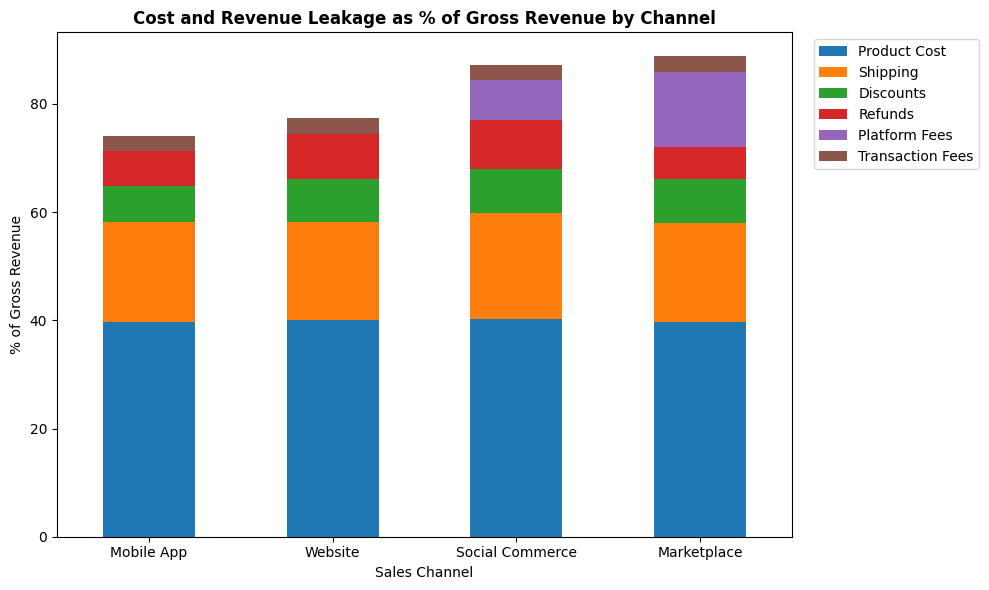

In [108]:
plot_data = channel_driver_summary.set_index("channel")[[f"{c}_pct" for c in cost_columns]]
ax = plot_data.plot(kind="bar", stacked=True, figsize=(10, 6))
ax.set_title("Cost and Revenue Leakage as % of Gross Revenue by Channel", fontweight="bold")
ax.set_xlabel("Sales Channel")
ax.set_ylabel("% of Gross Revenue")
plt.xticks(rotation=0)
plt.legend(["Product Cost", "Shipping", "Discounts", "Refunds", "Platform Fees", "Transaction Fees"], bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/images/channel_cost_drivers.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding:** Website generates the highest absolute profit (about **$25.12K**), while Mobile App has the highest margin (about **29.8%**). Marketplace has the lowest margin (about **13.0%**). Its product and shipping cost ratios are similar to Mobile App, but Marketplace platform fees are about **13.8% of gross revenue**, making fees an important recorded structural difference. Social Commerce has about **15.4% margin** and the highest channel return rate.

### 5. Returns Analysis
Estimate recorded revenue lost to returns using `refund_amount`. This is refunded revenue, not the full economic cost of returns (e.g., reverse logistics is not separately provided).

In [109]:
# Return summary

returned_orders = (orders["returned"] == "Yes").sum()
total_orders = len(orders)

print(f"Returned Orders (Yes): {returned_orders:,}")
print(f"Total Orders: {total_orders:,}")

Returned Orders (Yes): 144
Total Orders: 2,000


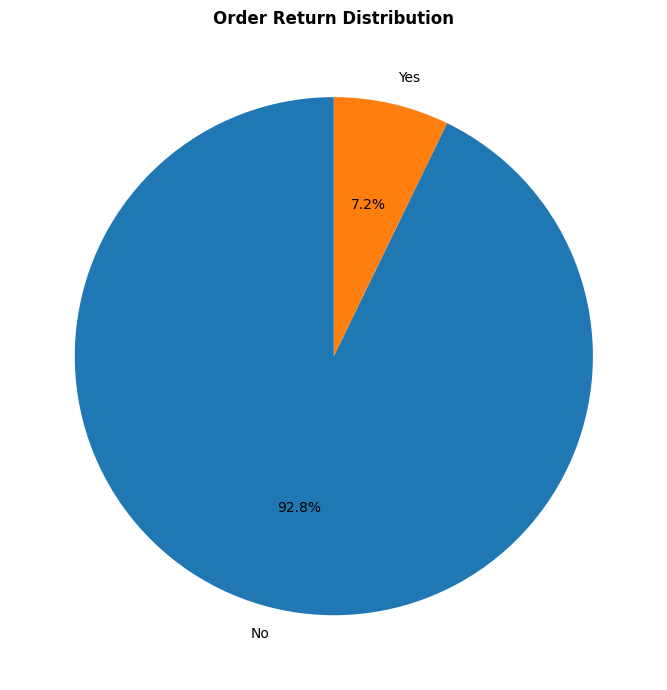

In [110]:
# Count Returned values
return_counts = orders["returned"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    return_counts.values,
    labels=return_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Order Return Distribution",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../outputs/images/return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Finding:** 144 of 2,000 orders were returned (**7.2%**), and recorded refunds total **$20,582.45**. Social Commerce has the highest channel return rate (about **9.1%**). Returns matter, but they do not independently determine profitability: Electronics remains the highest-margin category despite a relatively high return rate.

### 6. Marketing Performance
Aggregate ratios must be recalculated from totals rather than averaging row-level ROAS/CPC/CPA.

In [111]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               144 non-null    object 
 1   platform            144 non-null    object 
 2   spend               144 non-null    float64
 3   impressions         144 non-null    int64  
 4   clicks              144 non-null    int64  
 5   conversions         144 non-null    int64  
 6   revenue_attributed  144 non-null    float64
 7   cpc                 144 non-null    float64
 8   cpa                 144 non-null    float64
 9   roas                144 non-null    float64
 10  year                144 non-null    int64  
 11  month_number        144 non-null    int64  
 12  month_name          144 non-null    object 
dtypes: float64(5), int64(5), object(3)
memory usage: 14.8+ KB


In [112]:
# correct date type
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="raise"
)

marketing["month"] = pd.to_datetime(
    marketing["month"],
    errors="raise"
)


In [113]:
platform_performance = (
    marketing.groupby("platform")
    .agg(
        spend=("spend", "sum"), impressions=("impressions", "sum"), clicks=("clicks", "sum"),
        conversions=("conversions", "sum"), revenue_attributed=("revenue_attributed", "sum")
    ).reset_index()
)
platform_performance["roas"] = platform_performance["revenue_attributed"] / platform_performance["spend"]
platform_performance["cpc"] = platform_performance["spend"] / platform_performance["clicks"]
platform_performance["cpa"] = platform_performance["spend"] / platform_performance["conversions"]
platform_performance = platform_performance.sort_values("roas", ascending=False)
display(platform_performance.round(2))

,platform,spend,impressions,clicks,conversions,revenue_attributed,roas,cpc,cpa
5,TikTok Ads,57229.22,20750539,383269,18684,1374627.17,24.02,0.15,3.06
3,Influencer,97663.12,9990653,587501,28824,2216974.26,22.70,0.17,3.39
4,Instagram Ads,65154.02,11373438,306843,13863,1024639.06,15.73,0.21,4.70
2,Google Ads,152546.48,17529367,611740,32309,2194120.83,14.38,0.25,4.72
1,Facebook Ads,106451.93,16305609,331746,16968,1218572.43,11.45,0.32,6.27
0,Email Marketing,24461.37,636743,25971,1370,117681.45,4.81,0.94,17.86


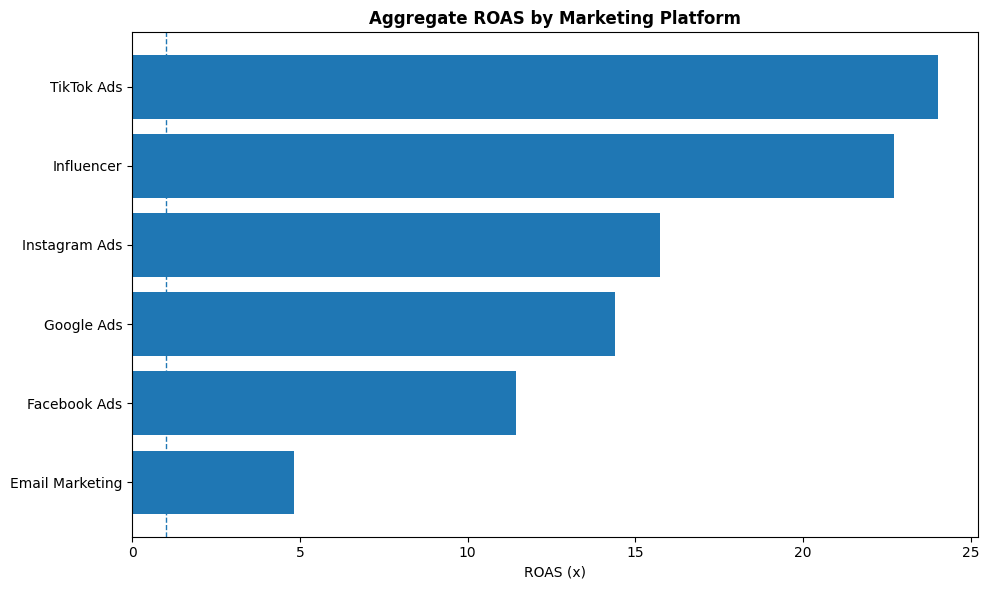

In [114]:
plot_df = platform_performance.sort_values("roas")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["platform"], plot_df["roas"])
ax.axvline(1, linestyle="--", linewidth=1)
ax.set_title("Aggregate ROAS by Marketing Platform", fontweight="bold")
ax.set_xlabel("ROAS (x)")
plt.tight_layout()
plt.savefig("../outputs/images/marketing_roas.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding:** TikTok Ads has the highest aggregate ROAS (about **24.0x**), followed by Influencer (about **22.7x**). Email Marketing has the lowest aggregate ROAS (about **4.8x**) and the highest CPC/CPA. No platform has aggregate ROAS below 1x; however, some individual platform-months do. ROAS measures attributed revenue per ad dollar, not profit after product/order costs.

### 7. Time-Trend Analysis
Orders span **2024-01-28 to 2026-01-11**, so January 2024 and January 2026 are partial months. Monthly trend interpretation focuses on complete months from February 2024 through December 2025.

In [115]:
monthly_performance = (
    orders.groupby("order_month")
    .agg(
        orders=("order_id", "count"), gross_revenue=("gross_revenue", "sum"),
        discount_amount=("discount_amount", "sum"), refund_amount=("refund_amount", "sum"),
        net_revenue=("net_revenue", "sum"), total_costs=("total_costs", "sum"),
        profit=("profit", "sum")
    ).reset_index()
)
monthly_performance["profit_margin"] = monthly_performance["profit"] / monthly_performance["net_revenue"]
monthly_performance["avg_order_value"] = monthly_performance["net_revenue"] / monthly_performance["orders"]
complete_months = monthly_performance[(monthly_performance["order_month"] >= "2024-02-01") & (monthly_performance["order_month"] <= "2025-12-01")].copy()
print("Complete months used for trend interpretation:", len(complete_months))

Complete months used for trend interpretation: 23


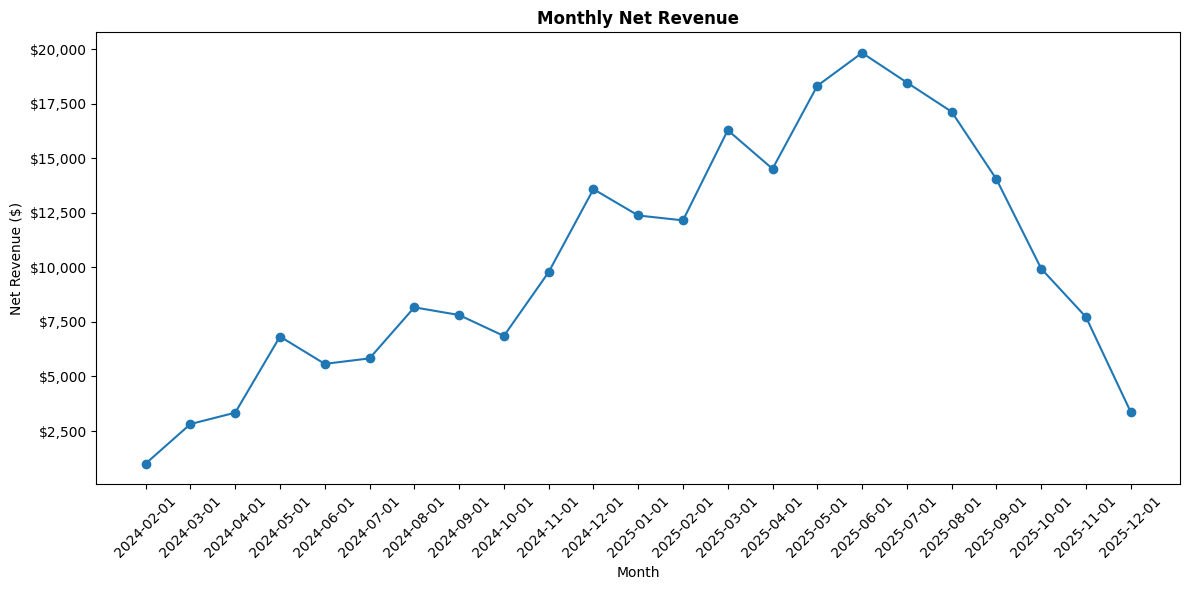

In [116]:
# monthly net revenue
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    complete_months["order_month"],
    complete_months["net_revenue"],
    marker="o"
)

ax.set_title(
    "Monthly Net Revenue",
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Net Revenue ($)")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/images/monthly_net_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

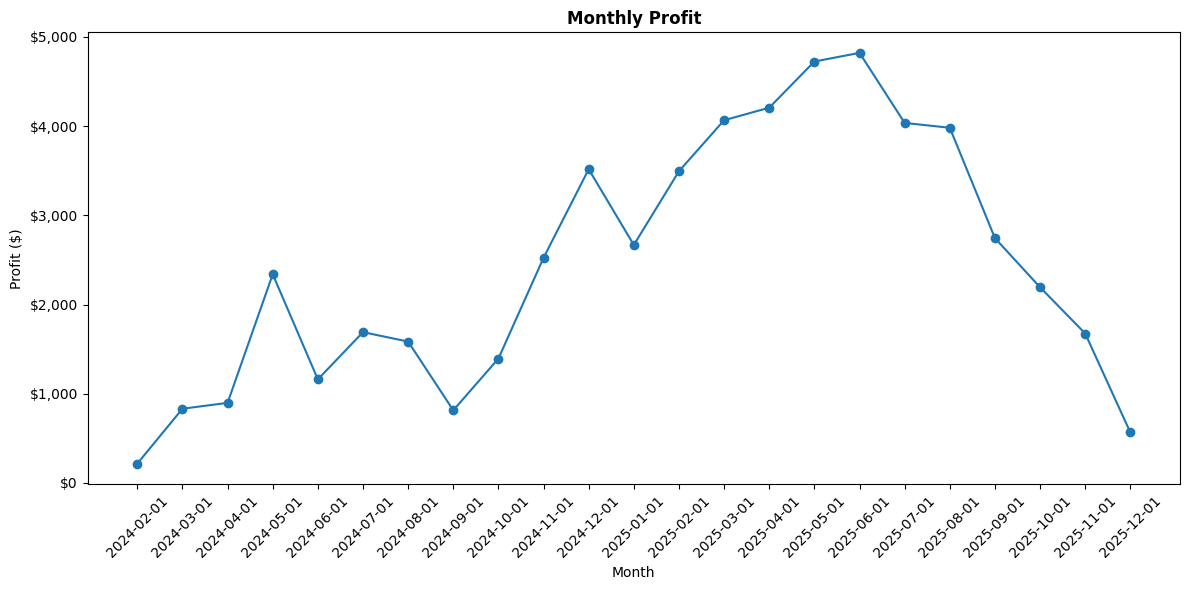

In [117]:
# monthly profit
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    complete_months["order_month"],
    complete_months["profit"],
    marker="o"
)

ax.set_title(
    "Monthly Profit",
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Profit ($)")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/images/monthly_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

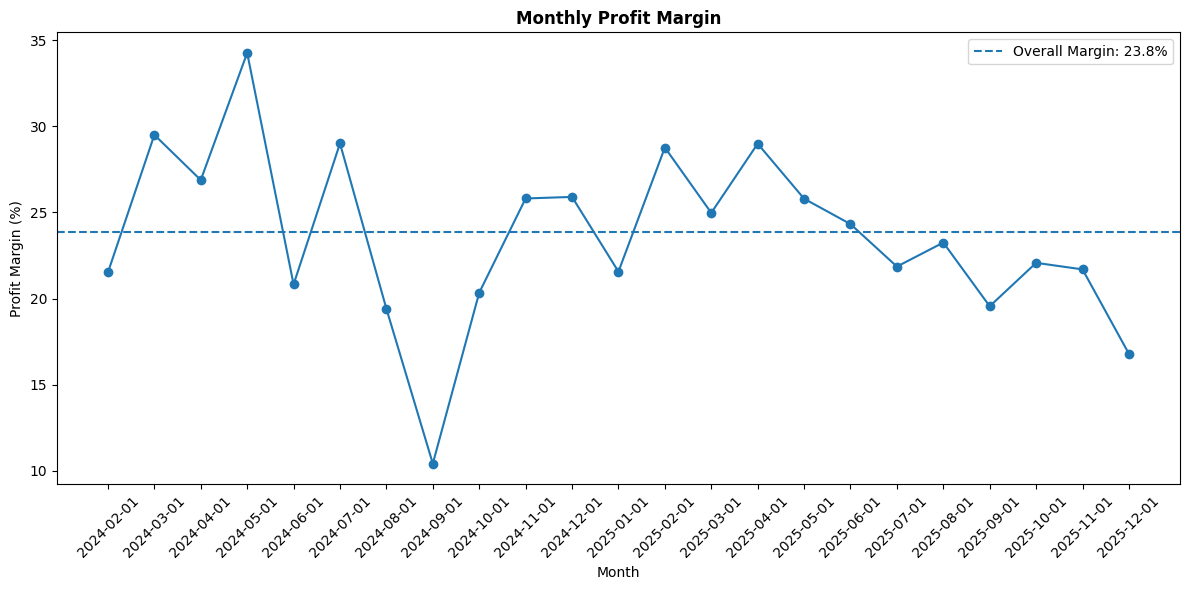

In [118]:
# monthly profit margin
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    complete_months["order_month"],
    complete_months["profit_margin"] * 100,
    marker="o"
)

# Overall profit margin reference line
ax.axhline(
    profit_margin * 100,
    linestyle="--",
    label=f"Overall Margin: {profit_margin:.1%}"
)

ax.set_title(
    "Monthly Profit Margin",
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Profit Margin (%)")

ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/images/monthly_profit_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [119]:
# Monthly Return amount
monthly_returns = (
    orders
    .groupby("order_month")
    .agg(
        total_orders=("order_id", "count"),
        returned_orders=("returned", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

monthly_returns["return_rate"] = (
    monthly_returns["returned_orders"]
    / monthly_returns["total_orders"]
)

display(monthly_returns)

,order_month,total_orders,returned_orders,return_rate
0,2024-01-01,2,0,0.000000
1,2024-02-01,8,0,0.000000
2,2024-03-01,20,1,0.050000
3,2024-04-01,24,2,0.083333
4,2024-05-01,39,2,0.051282
5,2024-06-01,44,2,0.045455
6,2024-07-01,40,2,0.050000
7,2024-08-01,69,5,0.072464
8,2024-09-01,80,6,0.075000
9,2024-10-01,76,8,0.105263


In [120]:
overall_return_rate = (
    (orders["returned"] == "Yes").sum()
    / len(orders)
)

print(f"Overall Return Rate: {overall_return_rate:.2%}")

Overall Return Rate: 7.20%


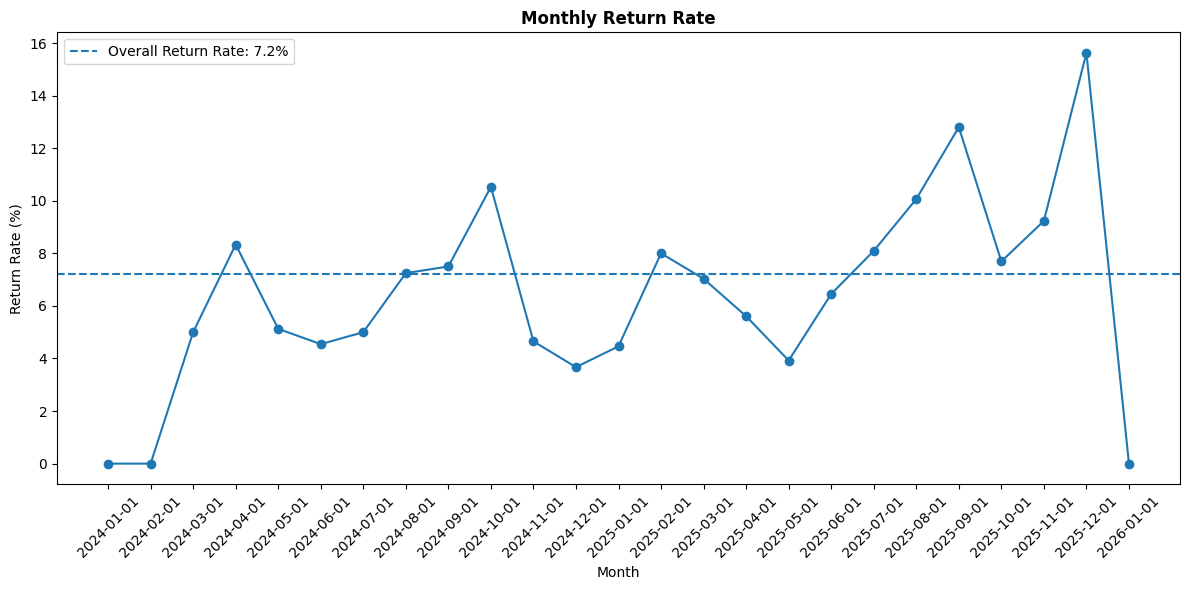

In [121]:
# monthly return rate

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_returns["order_month"],
    monthly_returns["return_rate"] * 100,
    marker="o"
)

# Overall return rate reference line
ax.axhline(
    overall_return_rate * 100,
    linestyle="--",
    label=f"Overall Return Rate: {overall_return_rate:.1%}"
)

ax.set_title(
    "Monthly Return Rate",
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Return Rate (%)")

ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/images/monthly_return_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [126]:
# Create year column if it does not already exist
orders["order_year"] = orders["order_date"].dt.year


# Aggregate performance by year
year_comparison = (
    orders
    .groupby("order_year")
    .agg(
        orders=("order_id", "count"),
        returned_orders=("returned", lambda x: (x == "Yes").sum()),
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        total_costs=("total_costs", "sum"),
        profit=("profit", "sum"),
        refund_amount=("refund_amount", "sum")
    )
    .reset_index()
)


# Calculate profit margin
year_comparison["profit_margin"] = (
    year_comparison["profit"]
    / year_comparison["net_revenue"]
)


# Calculate return rate
year_comparison["return_rate"] = (
    year_comparison["returned_orders"]
    / year_comparison["orders"]
)


display(year_comparison.round(4))

,order_year,orders,returned_orders,gross_revenue,net_revenue,total_costs,profit,refund_amount,profit_margin,return_rate
0,2024,597,36,84875.17,71898.71,54857.36,17041.35,6379.46,0.2370,0.0603
1,2025,1400,108,192773.13,164116.34,124938.14,39178.20,14202.99,0.2387,0.0771
2,2026,3,0,320.83,303.32,189.04,114.28,0.00,0.3768,0.0000


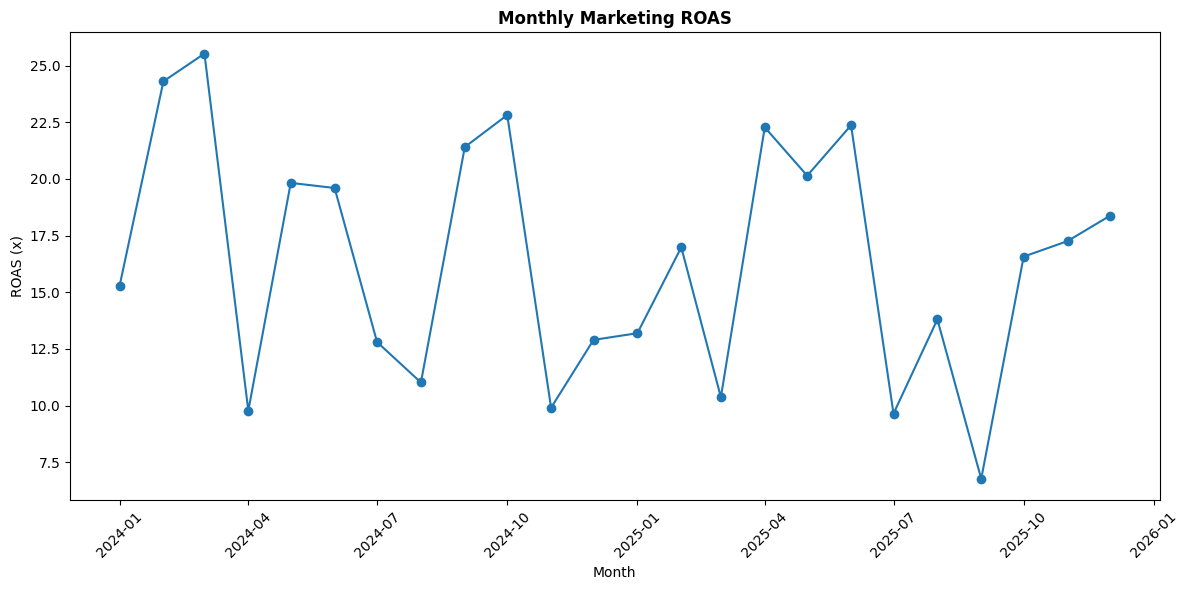

In [127]:
monthly_marketing_performance = marketing.groupby("month").agg(
    spend=("spend", "sum"), revenue_attributed=("revenue_attributed", "sum"),
    clicks=("clicks", "sum"), conversions=("conversions", "sum")
).reset_index()
monthly_marketing_performance["roas"] = monthly_marketing_performance["revenue_attributed"] / monthly_marketing_performance["spend"]
monthly_marketing_performance["cpc"] = monthly_marketing_performance["spend"] / monthly_marketing_performance["clicks"]
monthly_marketing_performance["cpa"] = monthly_marketing_performance["spend"] / monthly_marketing_performance["conversions"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_marketing_performance["month"], monthly_marketing_performance["roas"], marker="o")
ax.set_title("Monthly Marketing ROAS", fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("ROAS (x)")
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig("../outputs/images/monthly_marketing_roas.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation limitation:** Marketing-attributed revenue and order-level net revenue are different measures at different grains. Without an order-level attribution key, any relationship between marketing spend and total order revenue is descriptive rather than causal.

### 8. Profitability Waterfall
Explain how gross revenue is reduced by discounts, refunds, and operating costs before becoming profit.

In [128]:
bridge = pd.DataFrame({
    "Component": ["Gross Revenue", "Discounts", "Refunds", "Product Cost", "Shipping Cost", "Platform Fees", "Transaction Fees", "Profit"],
    "Amount": [
        orders["gross_revenue"].sum(), -orders["discount_amount"].sum(), -orders["refund_amount"].sum(),
        -orders["product_cost"].sum(), -orders["shipping_cost"].sum(), -orders["platform_fee"].sum(),
        -orders["transaction_fee"].sum(), orders["profit"].sum()
    ]
})
calculated_profit = bridge.loc[bridge["Component"] != "Profit", "Amount"].sum()
assert np.isclose(calculated_profit, profit, atol=0.01)
display(bridge)

profit_bridge_summary = pd.DataFrame({
    "Component": ["Discounts", "Refunds", "Product Cost", "Shipping Cost", "Platform Fees", "Transaction Fees", "Profit"],
    "Amount": [orders["discount_amount"].sum(), orders["refund_amount"].sum(), orders["product_cost"].sum(), orders["shipping_cost"].sum(), orders["platform_fee"].sum(), orders["transaction_fee"].sum(), orders["profit"].sum()]
})
profit_bridge_summary["pct_of_gross_revenue"] = profit_bridge_summary["Amount"] / gross_revenue * 100
display(profit_bridge_summary.round(2))

,Component,Amount
0,Gross Revenue,277969.13
1,Discounts,-21068.31
2,Refunds,-20582.45
3,Product Cost,-110933.95
4,Shipping Cost,-51105.86
5,Platform Fees,-9894.62
6,Transaction Fees,-8050.11
7,Profit,56333.83


,Component,Amount,pct_of_gross_revenue
0,Discounts,21068.31,7.58
1,Refunds,20582.45,7.40
2,Product Cost,110933.95,39.91
3,Shipping Cost,51105.86,18.39
4,Platform Fees,9894.62,3.56
5,Transaction Fees,8050.11,2.90
6,Profit,56333.83,20.27


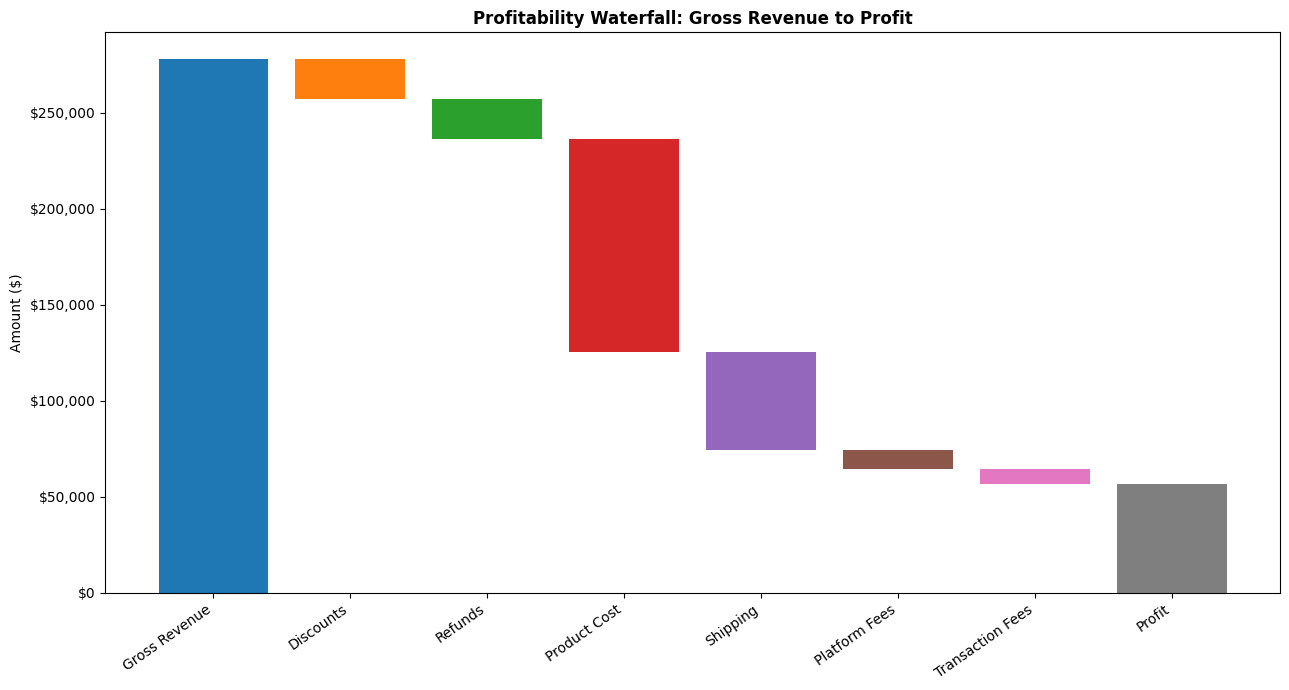

In [129]:
# Waterfall-style bridge
components = ["Gross Revenue", "Discounts", "Refunds", "Product Cost", "Shipping", "Platform Fees", "Transaction Fees", "Profit"]
changes = [gross_revenue, -orders["discount_amount"].sum(), -orders["refund_amount"].sum(), -orders["product_cost"].sum(), -orders["shipping_cost"].sum(), -orders["platform_fee"].sum(), -orders["transaction_fee"].sum()]
running = [changes[0]]
for ch in changes[1:]: running.append(running[-1] + ch)
fig, ax = plt.subplots(figsize=(13, 7))
ax.bar(components[0], changes[0])
for i in range(1, len(changes)):
    ax.bar(components[i], abs(changes[i]), bottom=running[i])
ax.bar(components[-1], profit)
ax.set_title("Profitability Waterfall: Gross Revenue to Profit", fontweight="bold")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig("../outputs/images/profitability_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

**Finding:** Gross revenue of about **$277.97K** becomes **$236.32K net revenue** after discounts and refunds, then **$56.33K profit** after recorded operating costs. Product cost is the largest cost component, followed by shipping.

### 9. 20% Marketing Budget Reduction Scenario
The stakeholder's requested reduction equals 20% of total recorded marketing spend. Rank platform-months by historical ROAS and build a mechanical review scenario. This is **not** a causal forecast: cutting spend may change conversions/revenue nonlinearly.

In [130]:
total_marketing_spend = marketing["spend"].sum()
reduction_target = total_marketing_spend * 0.20
remaining_budget = total_marketing_spend - reduction_target
print(f"Current marketing spend: ${total_marketing_spend:,.2f}")
print(f"20% reduction target:   ${reduction_target:,.2f}")
print(f"Remaining budget:       ${remaining_budget:,.2f}")

budget_scenario = marketing.copy()
budget_scenario["calculated_roas"] = budget_scenario["revenue_attributed"] / budget_scenario["spend"]
budget_scenario = budget_scenario.sort_values(["calculated_roas", "spend"]).reset_index(drop=True)
budget_scenario["cumulative_spend"] = budget_scenario["spend"].cumsum()
budget_scenario["cumulative_spend_pct"] = budget_scenario["cumulative_spend"] / total_marketing_spend

display(budget_scenario[["month", "platform", "spend", "revenue_attributed", "calculated_roas", "cumulative_spend"]].head(15).round(2))

Current marketing spend: $503,506.14
20% reduction target:   $100,701.23
Remaining budget:       $402,804.91


,month,platform,spend,revenue_attributed,calculated_roas,cumulative_spend
0,2025-12-01,Email Marketing,1796.66,1198.99,0.67,1796.66
1,2025-10-01,Email Marketing,791.74,959.52,1.21,2588.40
2,2025-07-01,Email Marketing,1362.00,2364.53,1.74,3950.40
3,2024-06-01,Email Marketing,942.79,1694.39,1.80,4893.19
4,2025-09-01,Facebook Ads,3877.76,9733.42,2.51,8770.95
5,2024-10-01,Email Marketing,1040.57,2620.57,2.52,9811.52
6,2024-08-01,Facebook Ads,5418.73,16769.26,3.09,15230.25
7,2025-06-01,Email Marketing,1293.73,4167.46,3.22,16523.98
8,2025-03-01,Google Ads,4709.29,15626.52,3.32,21233.27
9,2025-11-01,Email Marketing,1555.69,5230.26,3.36,22788.96


In [131]:
# Build exact mechanical 20% review pool, allowing a partial cut in the boundary row.
rows = []
remaining = reduction_target
for _, r in budget_scenario.iterrows():
    if remaining <= 0:
        break
    proposed_cut = min(r["spend"], remaining)
    rows.append({
        "month": r["month"], "platform": r["platform"], "historical_spend": r["spend"],
        "historical_revenue_attributed": r["revenue_attributed"], "roas": r["calculated_roas"],
        "proposed_review_amount": proposed_cut,
        "share_of_row_spend_reviewed": proposed_cut / r["spend"]
    })
    remaining -= proposed_cut
budget_review_candidates = pd.DataFrame(rows)
print("Scenario review amount:", f"${budget_review_candidates['proposed_review_amount'].sum():,.2f}")
print("Candidate rows:", len(budget_review_candidates))
display(budget_review_candidates.round(4))

Scenario review amount: $100,701.23
Candidate rows: 34


,month,platform,historical_spend,historical_revenue_attributed,roas,proposed_review_amount,share_of_row_spend_reviewed
0,2025-12-01,Email Marketing,1796.66,1198.99,0.6673,1796.660,1.0000
1,2025-10-01,Email Marketing,791.74,959.52,1.2119,791.740,1.0000
2,2025-07-01,Email Marketing,1362.00,2364.53,1.7361,1362.000,1.0000
3,2024-06-01,Email Marketing,942.79,1694.39,1.7972,942.790,1.0000
4,2025-09-01,Facebook Ads,3877.76,9733.42,2.5101,3877.760,1.0000
5,2024-10-01,Email Marketing,1040.57,2620.57,2.5184,1040.570,1.0000
6,2024-08-01,Facebook Ads,5418.73,16769.26,3.0947,5418.730,1.0000
7,2025-06-01,Email Marketing,1293.73,4167.46,3.2213,1293.730,1.0000
8,2025-03-01,Google Ads,4709.29,15626.52,3.3182,4709.290,1.0000
9,2025-11-01,Email Marketing,1555.69,5230.26,3.3620,1555.690,1.0000


A 20% reduction represents approximately $100,701 of the current $503,506 marketing budget. Budget reductions should prioritize the lowest-ROAS platform-month combinations rather than applying equal cuts across all platforms. Email Marketing, particularly December 2025, should receive priority review after generating only $0.67 in attributed revenue for every $1 spent. Lower-performing Facebook Ads and Google Ads periods can provide additional reduction opportunities until the $100,701 target is reached, while stronger historical performers such as TikTok Ads and Influencer Marketing receive lower priority for reductions. Gradual budget adjustments are recommended because historical ROAS identifies past spending efficiency but does not guarantee the future revenue impact of reduced marketing spend.

In [132]:
from pathlib import Path


pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)


In [133]:
# Export only decision-relevant outputs used in the final project story.
headline_kpis.to_csv(TABLE_DIR / "headline_kpis.csv", index=False)
category_profitability.to_csv(TABLE_DIR / "category_profitability.csv", index=False)
category_driver_summary.to_csv(TABLE_DIR / "category_profitability_drivers.csv", index=False)
channel_profitability.to_csv(TABLE_DIR / "channel_profitability.csv", index=False)
channel_driver_summary.to_csv(TABLE_DIR / "channel_profitability_drivers.csv", index=False)
platform_performance.to_csv(TABLE_DIR / "marketing_platform_performance.csv", index=False)
monthly_performance.to_csv(TABLE_DIR / "monthly_business_performance.csv", index=False)
monthly_marketing_performance.to_csv(TABLE_DIR / "monthly_marketing_performance.csv", index=False)
year_comparison.to_csv(TABLE_DIR / "comparable_period_year_summary.csv", index=False)
profit_bridge_summary.to_csv(TABLE_DIR / "profitability_bridge.csv", index=False)
budget_scenario.to_csv(TABLE_DIR / "marketing_budget_ranked_all_months.csv", index=False)
budget_review_candidates.to_csv(TABLE_DIR / "marketing_budget_review_candidates.csv", index=False)

print("Final tables exported to", TABLE_DIR)


Final tables exported to c:\Users\User\Desktop\Application_2026\Project_Series\Python_project_Series\E-commerce Profility Analysis\outputs\tables


## Key Findings

### 1. Profitability by Product Category

**Electronics** delivered the strongest category performance, generating
**$13,973 in profit** with a **31.13% profit margin**. **Books** recorded the
lowest margin at **11.94%**, followed by **Beauty at 17.39%**.

Shipping cost represents a major difference between high- and low-margin
categories. Shipping accounted for approximately **27.94% of gross revenue
for Books** and **24.79% for Beauty**, compared with only **13.50% for
Electronics**. Product cost ratios were comparatively similar across these
categories.

**Finding:** High shipping-cost pressure is associated with weaker margins,
particularly for Books and Beauty, making shipping economics an important
area for profitability review.


### 2. Profitability by Sales Channel

**Website** generated the highest total profit at approximately **$25,118**,
while **Mobile App** achieved the highest profit margin at **29.76%**.
Website also maintained a strong **27.01% margin**.

**Marketplace** recorded the lowest profit margin at **13.03%**, with platform
fees representing approximately **13.79% of gross revenue**. **Social
Commerce** produced a **15.37% margin** and recorded the highest channel
return rate at **9.14%**.

**Finding:** Direct channels, particularly Mobile App and Website, generated
stronger profitability. Platform fees create substantial margin pressure for
Marketplace, while Social Commerce faces additional pressure from a higher
return rate.


### 3. Return Performance

A total of **144 out of 2,000 orders were returned**, producing an overall
return rate of **7.20%** and approximately **$20,582 in refunded revenue**.

At category level, **Electronics recorded an 8.61% return rate**, followed by
**Books at 8.37%** and **Clothing at 8.19%**. At channel level, **Social
Commerce recorded the highest return rate at 9.14%**.

**Finding:** Returns represent a meaningful revenue leakage, but high return
rates do not automatically indicate low profitability. Electronics maintained
the highest category margin despite a relatively high return rate. Return
performance should therefore be evaluated together with revenue, costs, and
profitability rather than in isolation.


### 4. Marketing Platform Performance

**TikTok Ads** generated the strongest aggregate ROAS at approximately
**24.02x**, followed by **Influencer Marketing at 22.70x**. TikTok Ads also
recorded a low **$0.15 CPC** and **$3.06 CPA**, indicating strong historical
marketing efficiency.

**Email Marketing** recorded the weakest aggregate performance, with
**4.81x ROAS**, approximately **$0.94 CPC**, and **$17.86 CPA**. Facebook Ads
also generated a comparatively lower **11.45x ROAS** and **$6.27 CPA**.

**Finding:** TikTok Ads and Influencer Marketing generated the strongest
historical revenue efficiency, while Email Marketing showed the weakest
overall efficiency and the highest acquisition cost.


### 5. 20% Marketing Budget Reduction

Total marketing spend was approximately **$503,506**, making the required
20% reduction approximately **$100,701**.

Budget review should prioritize the **lowest historical ROAS platform-month
combinations** rather than applying equal reductions across all platforms.

**Email Marketing — December 2025** recorded the weakest result, with
**$1,796.66 in spend**, **$1,198.99 in attributed revenue**, and only
**0.67x ROAS**. Additional low-performing periods were identified across
Email Marketing, Facebook Ads, and Google Ads.

Historical ROAS ranking identified **34 platform-month observations** for
review to reach the approximately **$100,701 budget-reduction target**.

**Finding:** Lower-ROAS platform-month periods should receive priority for
controlled budget reductions or reallocation, while historically stronger
TikTok Ads and Influencer Marketing activity should receive lower priority
for reductions. Gradual adjustments and continued performance monitoring are
necessary because historical ROAS does not guarantee the future revenue impact
of reduced marketing spend.

# Recommendations

Based on the profitability, return, channel, and marketing performance analysis,
three priority actions are recommended to improve profitability.

## 1. Reduce Shipping Cost Pressure in Books and Beauty

**Books** recorded the lowest profit margin at **11.94%**, while **Beauty**
recorded a relatively low **17.39% margin**. Shipping costs represented
approximately **27.94% of gross revenue for Books** and **24.79% for Beauty**,
compared with only **13.50% for Electronics**, the highest-margin category at
**31.13%**.

**Recommended Action:** Review shipping rates, fulfillment arrangements,
free-shipping thresholds, and product-bundling opportunities for Books and
Beauty. Even a small reduction in shipping cost could improve margins in these
categories. Exact savings should be estimated only after operational shipping
options and costs are available.


## 2. Improve Marketplace and Social Commerce Profitability

Direct sales channels produced considerably stronger margins. **Mobile App
generated a 29.76% profit margin** and **Website generated 27.01%**, compared
with only **13.03% for Marketplace** and **15.37% for Social Commerce**.

Marketplace platform fees represented approximately **13.79% of gross
revenue**, creating substantial margin pressure. Social Commerce also recorded
the highest channel return rate at **9.14%**.

**Recommended Action:** Review Marketplace fees, pricing, discount strategy,
and product mix, while reviewing the causes of higher Social Commerce returns.
Opportunities to encourage appropriate purchases through Website and Mobile
App should also be evaluated because both direct channels currently retain a
larger share of revenue as profit.


## 3. Target the $100,701 Marketing Reduction at Lower-Performing Periods

Total marketing spend was approximately **$503,506**. A 20% reduction therefore
requires approximately **$100,701**, leaving about **$402,805** in the marketing
budget.

Budget reductions should focus first on historically lower-performing
platform-month combinations rather than reducing every platform equally.

**Email Marketing** requires particular review. December 2025 recorded
**$1,796.66 in spend but only $1,198.99 in attributed revenue**, producing
**0.67x ROAS**. Other low-performing periods were identified across Email
Marketing, Facebook Ads, and Google Ads.

The historical performance ranking identifies **34 platform-month observations**
for review to reach the approximately **$100,701 reduction target**.

**Recommended Action:** Begin controlled reductions with the lowest-performing
Email Marketing periods, followed by weaker Facebook Ads and Google Ads periods
as required. Historically stronger activity, including **TikTok Ads at 24.02x
aggregate ROAS** and **Influencer Marketing at 22.70x**, should receive lower
priority for reductions.

The $100,701 represents a budget-reduction target, not guaranteed savings with
no revenue impact. Gradual reductions and continued monitoring of sales and
conversions are recommended before permanent budget changes.